Dimensiones de X: (569, 30)
Distribución del target:
 target
0    212
1    357
Name: count, dtype: int64

Duplicados en el dataset: 0
¿El Target está dentro de X? False

Tamaños -> Train: (455, 30), Test: (114, 30)
F1 macro baseline: 0.3871

--- Reporte de Clasificación (SVM Base) ---
              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

ROC-AUC: 0.995


c:\Users\jesus\Cursos\1_Maestria Ciencia de Datos\Ciencia de dato II\Practicas\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


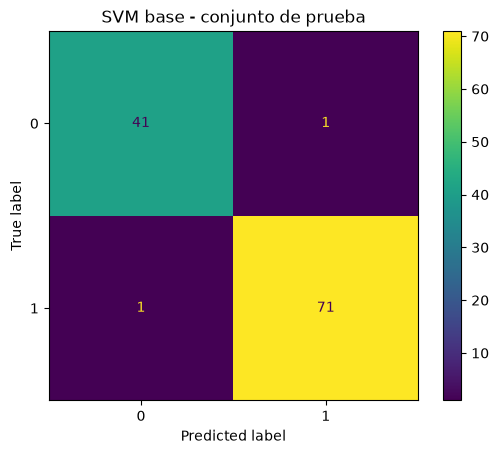

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 3. Cargar los datos
bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()
print("Dimensiones de X:", X.shape)
print("Distribución del target:\n", y.value_counts().sort_index())

# 4. Auditar antes de modelar
audit = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos": X.nunique()
})
print("\nDuplicados en el dataset:", X.duplicated().sum())
print("¿El Target está dentro de X?", y.name in X.columns)

# 5. Reservar prueba (Estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTamaños -> Train: {X_train.shape}, Test: {X_test.shape}")

# 6. Crear una línea base (Dummy Classifier)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("F1 macro baseline:", round(f1_score(y_test, dummy_pred, average="macro"), 4))

# 7. Construir la SVM correctamente mediante un Pipeline (Evita fuga de datos)
svm = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42))
])
svm.fit(X_train, y_train)

# 8. Evaluar la configuración base
pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1]
print("\n--- Reporte de Clasificación (SVM Base) ---")
print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

# Mostrar Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("SVM base - conjunto de prueba")
plt.show()

In [3]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    estimator=svm,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:", search.best_params_)
print("Mejor score CV (F1 Macro):", round(search.best_score_, 4))

# 10. Comparar variaciones y evaluar el mejor modelo en test
cv_results = pd.DataFrame(search.cv_results_)
columns = ["param_model__C", "param_model__gamma", "mean_test_score", "std_test_score", "mean_fit_time"]
print("\nTop combinaciones de GridSearch:")
display(cv_results[columns].sort_values("mean_test_score", ascending=False).head(9))

best = search.best_estimator_
best_pred = best.predict(X_test)
print("\n--- Reporte del Mejor Modelo Optimizado ---")
print(classification_report(y_test, best_pred, digits=4))

Mejores hiperparámetros encontrados: {'model__C': 10, 'model__gamma': 0.01}
Mejor score CV (F1 Macro): 0.9739

Top combinaciones de GridSearch:


c:\Users\jesus\Cursos\1_Maestria Ciencia de Datos\Ciencia de dato II\Practicas\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,param_model__C,param_model__gamma,mean_test_score,std_test_score,mean_fit_time
7,10.0,0.01,0.973888,0.017677,0.027621
4,1.0,0.01,0.969041,0.016283,0.030675
6,10.0,scale,0.967086,0.013638,0.034329
3,1.0,scale,0.966940,0.015966,0.039743
5,1.0,0.1,0.953323,0.012853,0.076349
1,0.1,0.01,0.942078,0.014347,0.174097
0,0.1,scale,0.937715,0.018035,0.128505
8,10.0,0.1,0.937532,0.023718,0.044243
2,0.1,0.1,0.934135,0.015687,0.108100



--- Reporte del Mejor Modelo Optimizado ---
              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



In [ ]:
from pathlib import Path

import joblib

Path("reports").mkdir(exist_ok=True)
cv_results[columns].to_csv("reports/svm_cv_results.csv", index=False)
joblib.dump(best, "reports/svm_best.joblib")
print("Resultados de validación y modelo optimizado guardados en reports/")

Resultados de validación y modelo optimizado guardados en reports/
